In [31]:
# region Imports

#* --------------------------------------------------------------------------------
#* General purpose imports
#* --------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import fisher_exact, barnard_exact, ranksums, spearmanr, permutation_test, kendalltau, pearsonr
from matplotlib.ticker import FuncFormatter
import pickle as pkl


#* --------------------------------------------------------------------------------
#* Personal librairies imports
#* --------------------------------------------------------------------------------
import sys, os
src_path = os.path.abspath(os.path.join("..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from utils import astro_utils as au
from utils import maths_utils  as mu
from utils import stats_utils  as su
from utils import graphics_utils  as gu
from utils import labels_utils  as lu
from utils import pandas_utils  as pu


#* --------------------------------------------------------------------------------
#* Project modules imports
#* --------------------------------------------------------------------------------
import sSFR
import generate_report as report
import domination

#* --------------------------------------------------------------------------------
#* Global variables
#* --------------------------------------------------------------------------------
import config as co

#* --------------------------------------------------------------------------------
#* Project data
#* --------------------------------------------------------------------------------

with open(co.DATA_PATH + co.PROCESS_SAMPLES, "rb") as file:
            sample = pkl.load(file)



# endregion

In [27]:
quantities = ['size_Group_Bary_kpc', 'Offset_Bary', 'Vdisp', 'Voffset','Lum_group']

In [25]:
p_lim = 5e-2

In [28]:
q_sig = []

for q in quantities:
    print(f"{q} Wilcoxon test dom vs non dom")
    sig=False
    for cat in co.SAMPLE:
        df = sample[cat+co.GRSUFF]
        df_dom = df[df['is_dominated']]
        df_nondom = df[~df['is_dominated']]

        if (df_dom[q].median() < df_nondom[q].median()):
            alternative = 'less'
        else:
            alternative = 'greater'
        statistic, p_value = ranksums(df_dom[q],df_nondom[q], alternative=alternative)
        print(f"  -- {cat} : \tp-value={p_value:.3f}      statistic={statistic:.2f}")  
        if p_value < p_lim:
            sig=True
    
    if sig:
        q_sig.append(q)
    print("\n")



size_Group_Bary_kpc Wilcoxon test dom vs non dom
  -- CG4 : 	p-value=0.225      statistic=0.76
  -- Control4B : 	p-value=0.002      statistic=-2.81
  -- Control4C : 	p-value=0.001      statistic=-3.28
  -- RG4 : 	p-value=0.006      statistic=-2.53


Offset_Bary Wilcoxon test dom vs non dom
  -- CG4 : 	p-value=0.432      statistic=-0.17
  -- Control4B : 	p-value=0.006      statistic=-2.53
  -- Control4C : 	p-value=0.002      statistic=-2.90
  -- RG4 : 	p-value=0.266      statistic=-0.62


Vdisp Wilcoxon test dom vs non dom
  -- CG4 : 	p-value=0.645      statistic=0.37
  -- Control4B : 	p-value=0.004      statistic=-2.64
  -- Control4C : 	p-value=0.000      statistic=4.40
  -- RG4 : 	p-value=0.294      statistic=0.54


Voffset Wilcoxon test dom vs non dom
  -- CG4 : 	p-value=0.017      statistic=-2.11
  -- Control4B : 	p-value=0.022      statistic=-2.01
  -- Control4C : 	p-value=0.029      statistic=-1.89
  -- RG4 : 	p-value=0.507      statistic=0.02


Lum_group Wilcoxon test dom vs non 

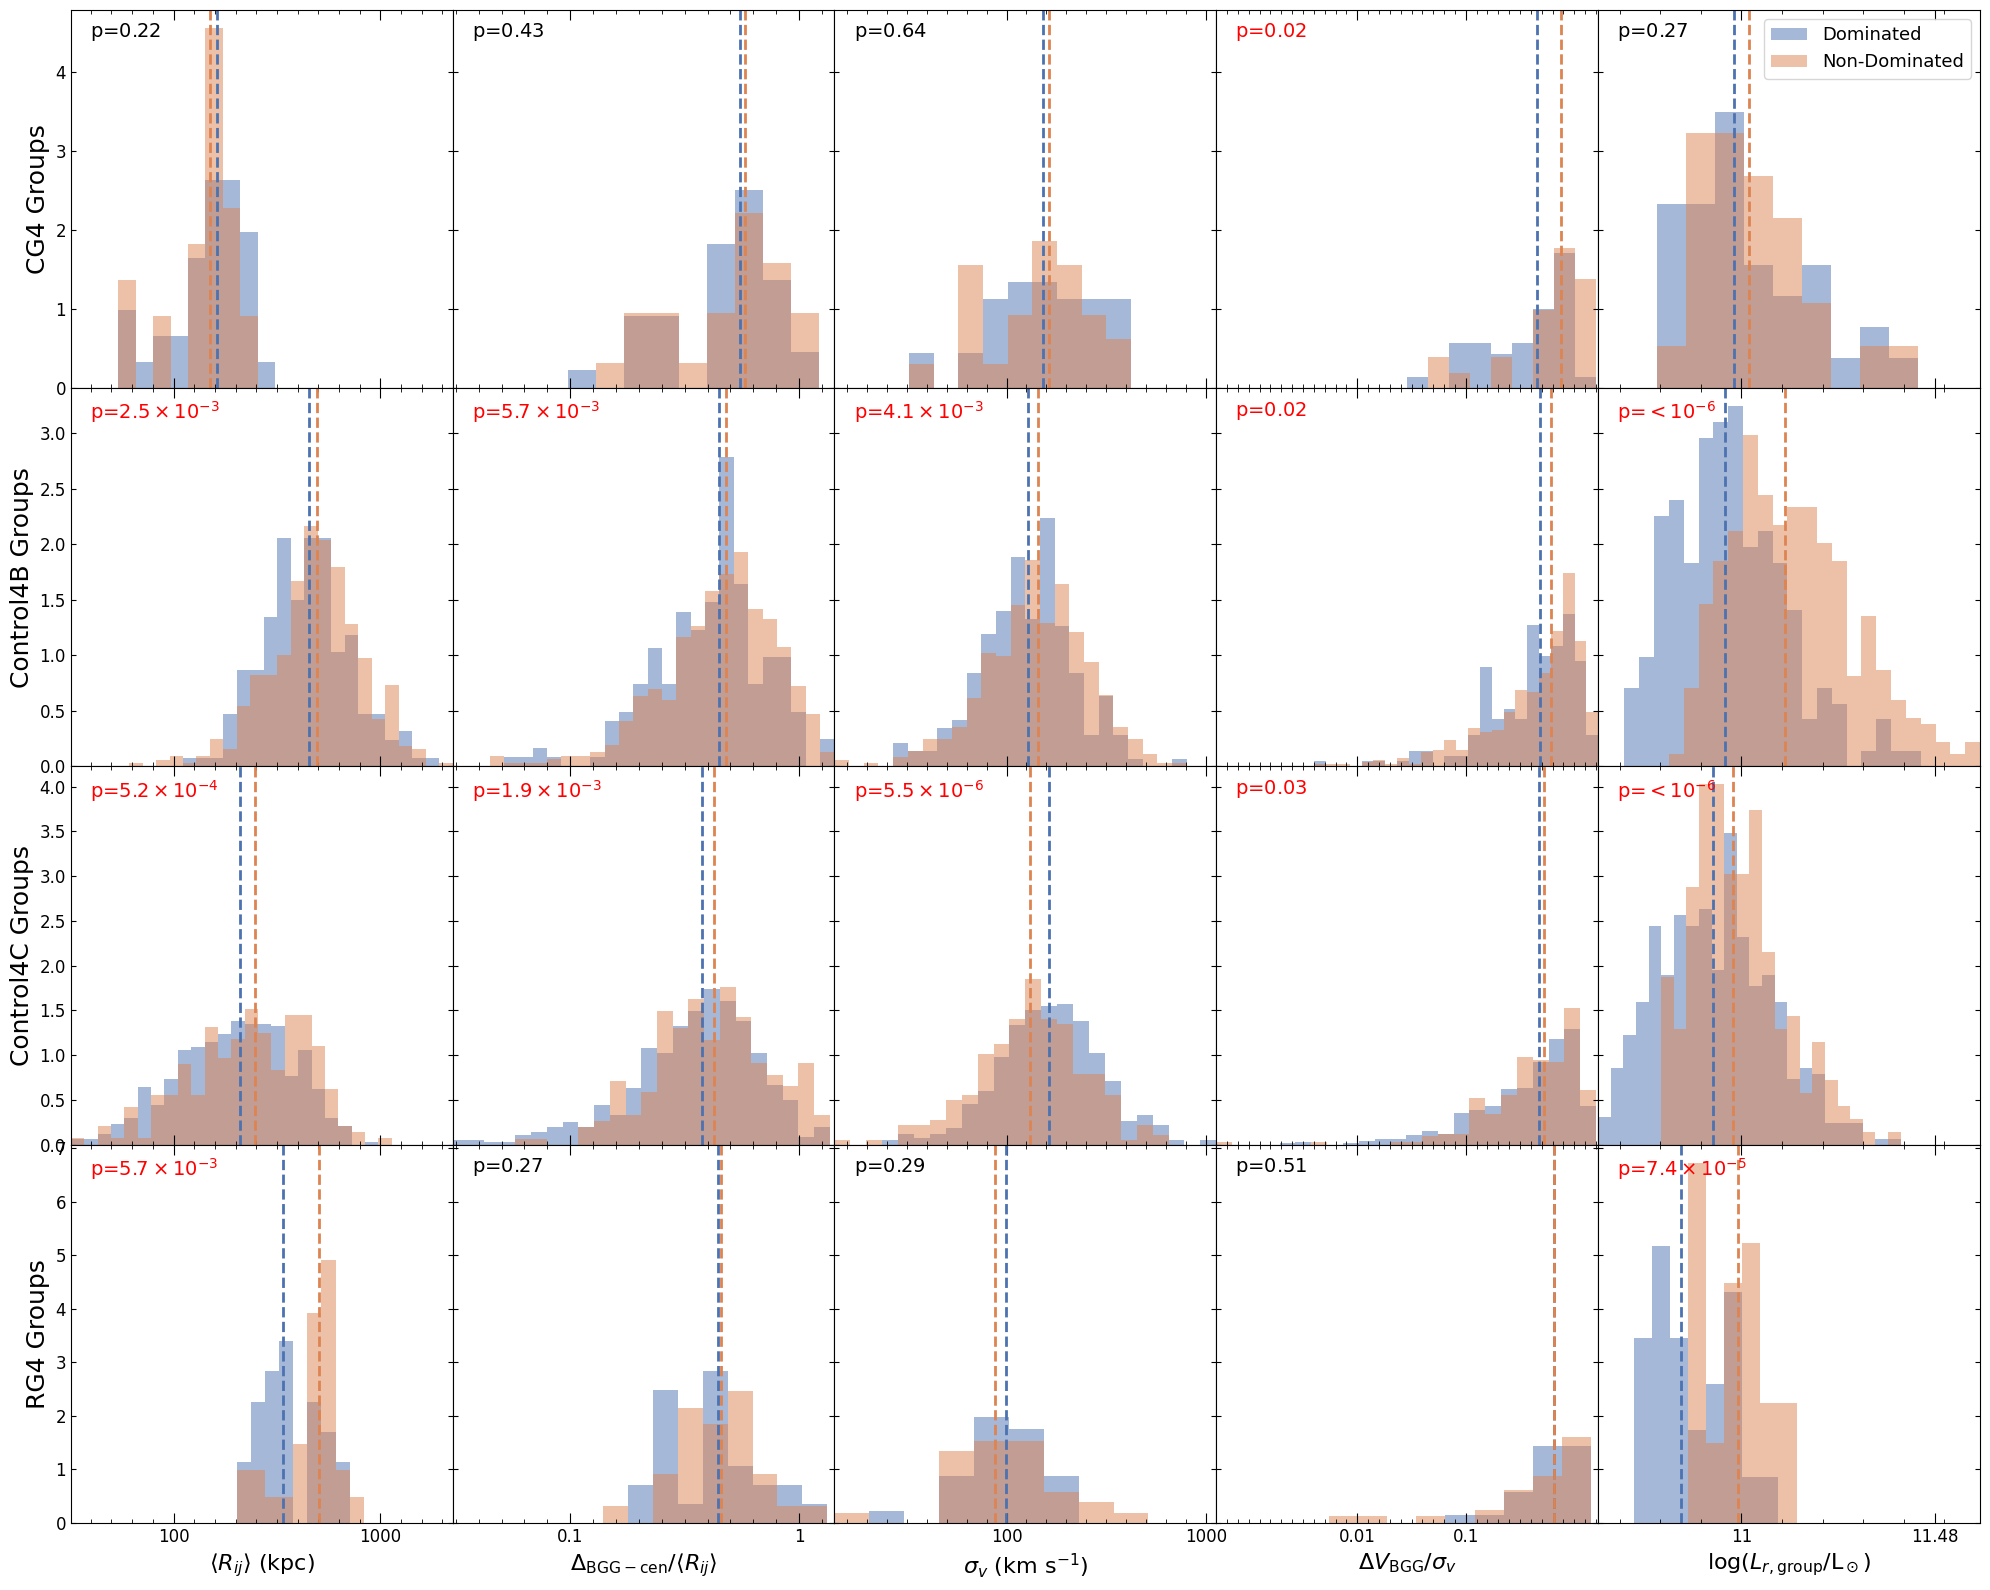

In [ ]:
# Dom_vs_NonDom

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator, MultipleLocator

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

name = "Dom_vs_NonDom"

dom_color    = "#4C72B0"   # muted blue
nondom_color = "#DD8452"   # muted orange

length = 4
title_size = 18
label_size = 16
legend_size = 13
pval_size = 14
tick_size = 12

nb_bin = {'CG4': 10, 'Control4B': 25, 'Control4C': 25, 'RG4': 10}

ncols = len(q_sig)
nrows = len(co.SAMPLE)

med_linewidth = 2.0
# Per-quantity round-number major tick overrides (LINEAR space)
custom_major_ticks = {
    "Lum_group": [3e10, 1e11, 3e11],
}

# ------------------------------------------------------------
# Formatters
#   - smart_log_formatter: axis is log10-space, labels are linear-space
#   - log_value_formatter: axis is log10-space, labels show log10 values
# ------------------------------------------------------------

def smart_log_formatter(x, pos):
    val = 10**x

    # ordinary notation in [0.01, 1000]
    if 1e-2 <= val <= 1e3:
        if val >= 100:
            return f"{val:.0f}"
        elif val >= 10:
            return f"{val:.1f}".rstrip("0").rstrip(".")
        else:
            return f"{val:.2f}".rstrip("0").rstrip(".")
    else:
        exp = int(np.floor(np.log10(val)))
        mant = val / 10**exp

        if np.isclose(mant, 1.0):
            return rf"$10^{{{exp}}}$"

        if np.isclose(mant, np.round(mant)):
            mant_str = str(int(np.round(mant)))
            return rf"${mant_str}\times10^{{{exp}}}$"

        return rf"${mant:.1f}\times10^{{{exp}}}$"


def log_value_formatter(x, pos):
    """Show the actual log10 value on a linear axis."""
    if np.isfinite(x):
        return f"{x:.2f}".rstrip("0").rstrip(".")
    return ""

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(length * ncols, length * nrows),
    gridspec_kw={'hspace': 0, 'wspace': 0}
)

# Collect limits (in log10 space for x)
col_xmin = np.full(ncols,  np.inf)
col_xmax = np.full(ncols, -np.inf)
row_ymax = np.zeros(nrows)   # densities are >= 0

# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------

for col, quantity in enumerate(q_sig):
    for row, cat in enumerate(co.SAMPLE):
        ax = axes[row, col]

        df = sample[cat + co.GRSUFF]
        df_dom = df[df['is_dominated']]
        df_nondom = df[~df['is_dominated']]

        # --- stats (guard against empty groups / NaNs)
        dom_vals = df_dom[quantity].to_numpy()
        nondom_vals = df_nondom[quantity].to_numpy()
        dom_vals = dom_vals[np.isfinite(dom_vals) & (dom_vals > 0)]
        nondom_vals = nondom_vals[np.isfinite(nondom_vals) & (nondom_vals > 0)]

        p_value = np.nan
        if dom_vals.size > 0 and nondom_vals.size > 0:
            alternative = 'less' if np.median(dom_vals) < np.median(nondom_vals) else 'greater'
            _, p_value = ranksums(dom_vals, nondom_vals, alternative=alternative)

        # --- histogram in log10 space
        vals = df[quantity].to_numpy()
        vals = vals[np.isfinite(vals) & (vals > 0)]
        if vals.size == 0:
            continue

        bins = np.linspace(np.log10(vals.min()), np.log10(vals.max()), nb_bin[cat])

        # update per-column x-range (log10)
        col_xmin[col] = min(col_xmin[col], bins.min())
        col_xmax[col] = max(col_xmax[col], bins.max())

        # plot (still in log10-space for x)
        if dom_vals.size > 0:
            ax.hist(np.log10(dom_vals), bins=bins, density=True,
                    color=dom_color, alpha=0.5, label="Dominated")
            ax.axvline(np.log10(np.median(dom_vals)), color=dom_color, linestyle='--', linewidth=med_linewidth)

        if nondom_vals.size > 0:
            ax.hist(np.log10(nondom_vals), bins=bins, density=True,
                    color=nondom_color, alpha=0.5, label="Non-Dominated")
            ax.axvline(np.log10(np.median(nondom_vals)), color=nondom_color, linestyle='--', linewidth=med_linewidth)

        # update per-row y max
        row_ymax[row] = max(row_ymax[row], ax.get_ylim()[1])

        # --- axis titles
        if col == 0:
            ax.set_ylabel(f"{cat} Groups", fontsize=title_size)

        if row == nrows - 1:
            if col == ncols - 1:
                ax.set_xlabel(lu.formatted_label("log" + quantity), fontsize=label_size)
            else:
                ax.set_xlabel(lu.formatted_label(quantity), fontsize=label_size)

        # --- p-value
        if np.isfinite(p_value):
            ptxt = f"p={gu.tex_form(p_value)}"
            pcol = "red" if p_value <= co.P_LIMIT else "black"
        else:
            ptxt = "p=NA"
            pcol = "black"

        ax.text(
            0.05, 0.97,
            ptxt,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=pval_size,
            color=pcol
        )

        # --- legend (top-right subplot only)
        if col == ncols - 1 and row == 0:
            ax.legend(fontsize=legend_size)

# ------------------------------------------------------------
# Apply shared limits (before sharing)
# ------------------------------------------------------------

for col in range(ncols):
    for row in range(nrows):
        axes[row, col].set_xlim(col_xmin[col], col_xmax[col])

for row in range(nrows):
    for col in range(ncols):
        axes[row, col].set_ylim(0, row_ymax[row])

# ------------------------------------------------------------
# Share axes (grouped): x per column, y per row
# ------------------------------------------------------------

for col in range(ncols):
    base = axes[0, col]
    for row in range(1, nrows):
        axes[row, col].sharex(base)

for row in range(nrows):
    base = axes[row, 0]
    for col in range(1, ncols):
        axes[row, col].sharey(base)

# ------------------------------------------------------------
# Ticks & formatting (per column, AFTER limits)
#   - ≥4 major ticks normally
#   - allow custom overrides (e.g. Lum_group) with 3 round ticks
#   - last column shows LOG10 values as labels (linear in log space)
# ------------------------------------------------------------

for col, quantity in enumerate(q_sig):
    xmin = col_xmin[col]
    xmax = col_xmax[col]
    span = xmax - xmin

    # --- custom override (linear -> log10)
    if quantity in custom_major_ticks:
        ticks_lin = np.array(custom_major_ticks[quantity], dtype=float)
        ticks = np.log10(ticks_lin)
        ntarget = len(ticks)

    else:
        # choose a tick target that avoids overlaps for many columns
        if ncols >= 5:
            ntarget = 4
        elif ncols == 4:
            ntarget = 5
        else:
            ntarget = 6

        if span <= 1.5:
            ticks = np.linspace(xmin, xmax, ntarget)
        else:
            dmin = int(np.floor(xmin))
            dmax = int(np.ceil(xmax))

            decades = np.arange(dmin, dmax + 1, 1.0)

            # include mid-decade ticks only if we have room
            if len(decades) <= ntarget:
                mids = decades[:-1] + np.log10(3)
                ticks = np.sort(np.concatenate([decades, mids]))
            else:
                ticks = decades

            # thin if still too many (keep endpoints)
            if len(ticks) > ntarget:
                idx = np.linspace(0, len(ticks) - 1, ntarget).round().astype(int)
                ticks = ticks[idx]

            ticks = ticks[(ticks >= xmin) & (ticks <= xmax)]

    # apply to the whole column
    for row in range(nrows):
        ax = axes[row, col]
        ax.xaxis.set_major_locator(FixedLocator(ticks))

        # last column: display log10 values (linear labels)
        if col == ncols - 1:
            ax.xaxis.set_major_formatter(FuncFormatter(log_value_formatter))
        else:
            ax.xaxis.set_major_formatter(FuncFormatter(smart_log_formatter))

        # minor ticks (light)
        ax.xaxis.set_minor_locator(MultipleLocator(0.1))

# ------------------------------------------------------------
# Tick appearance & label visibility
#   - ticks on all 4 sides
#   - x tick labels only bottom row
#   - y tick labels only first column
# ------------------------------------------------------------

for row in range(nrows):
    for col in range(ncols):
        ax = axes[row, col]
        ax.tick_params(
            which='both',
            top=True, bottom=True, left=True, right=True,
            direction='in',
            labelsize=tick_size
        )
        ax.tick_params(axis='x', which='minor', length=3)
        ax.tick_params(axis='x', which='major', length=7)

        # x labels only bottom row
        if row != nrows - 1:
            ax.tick_params(axis='x', labelbottom=False)

        # y labels only first column
        if col != 0:
            ax.tick_params(axis='y', labelleft=False)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.tight_layout()

if name:
    fig.savefig(co.FIGURES_PATH + name + ".pdf", bbox_inches="tight", format="pdf")


In [7]:
from scipy.stats import spearmanr, permutation_test
from itertools import combinations

In [8]:
Corr = pd.DataFrame(columns=['Sample','Domination','Quantity1','Quantity2',
                             'Spear_corr','Spear_pval'])


for cat in co.SAMPLE.keys():
    grp = sample[cat+co.GRSUFF]

    for dom in [True, False]:
        df = grp[grp['is_dominated'] == dom]
        for q in combinations(quantities,2):
            spearcorr, spearpval = spearmanr(df[q[0]],df[q[1]])
            Corr=pu.append_df(Corr,{
                    'Sample'           : cat,
                    'Domination'       : dom,   
                    'Quantity1'        : q[0],
                    'Quantity2'        : q[1],
                    'Spear_corr'       : spearcorr,
                    'Spear_pval'       : spearpval
                    })



Corr = Corr.sort_values(by='Spear_pval',ascending = False).reset_index(drop=True)

In [9]:
Corr[Corr['Spear_pval']<0.05].sort_values(by=['Quantity1', 'Quantity2'],ascending = True).to_csv(co.DATA_PATH + "Spearman_Dom_vs_NonDom.csv", index=False)

In [10]:
from itertools import combinations
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, permutation_test, kendalltau, pearsonr

def spearman_stat(x, y, axis=-1):
    # permutation_test peut appeler avec axis, donc on le garde
    return spearmanr(x, y, axis=axis, nan_policy="omit").statistic

Corr = pd.DataFrame(columns=[
    "Sample","Domination","Quantity1","Quantity2",
    "Spear_corr","Spear_pval"
    # ,"Kendall_tau","Kendall_pval"
])

for cat in co.SAMPLE.keys():
    grp = sample[cat + co.GRSUFF]

    for dom in [True, False]:
        df = grp[grp["is_dominated"] == dom]

        for q0, q1 in combinations(quantities, 2):
            x = df[q0].to_numpy()
            y = df[q1].to_numpy()

            # (optionnel mais conseillé) virer les NaN de façon cohérente
            m = np.isfinite(x) & np.isfinite(y)
            x, y = x[m], y[m]

            spearcorr, spearpval = spearmanr(x, y)
            # kendalltau = kendalltau(x, y, nan_policy="omit")

            Corr = pu.append_df(Corr, {
                "Sample": cat,
                "Domination": dom,
                "Quantity1": q0,
                "Quantity2": q1,
                "Spear_corr": spearcorr,
                "Spear_pval": spearpval
                # ,
                # "Kendall_tau": kendalltau,
                # "Kendall_pval": kendallp,
            })

# en général on trie par pval croissante (plus significatif en haut)
Corr = Corr.sort_values(by="Spear_pval", ascending=True).reset_index(drop=True)

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, brunnermunzel, ks_2samp
from statsmodels.stats.multitest import multipletests

def cliffs_delta(a, b):
    # delta in [-1, 1] : >0 signifie a tend à être plus grand que b
    a = np.asarray(a); b = np.asarray(b)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a)==0 or len(b)==0:
        return np.nan
    # O(n*m) : OK si tu n’as pas des milliers partout; sinon on optimisera
    gt = sum((ai > b).sum() for ai in a)
    lt = sum((ai < b).sum() for ai in a)
    return (gt - lt) / (len(a)*len(b))

rows = []

for cat in co.SAMPLE.keys():
    grp = sample[cat + co.GRSUFF]

    dom = grp[grp["is_dominated"] == True]
    nod = grp[grp["is_dominated"] == False]

    for q in quantities:
        a = dom[q].to_numpy()
        b = nod[q].to_numpy()

        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]

        if len(a) < 5 or len(b) < 5:
            continue

        # Mann–Whitney (attention: “method” dispo selon versions SciPy)
        U, p_mwu = mannwhitneyu(a, b, alternative="two-sided")

        # Brunner–Munzel (robuste aux variances différentes)
        bm, p_bm = brunnermunzel(a, b, alternative="two-sided")

        # KS (différence globale)
        D, p_ks = ks_2samp(a, b, alternative="two-sided")

        # Taille d’effet
        d = cliffs_delta(a, b)

        rows.append({
            "Sample": cat,
            "Quantity": q,
            "n_dom": len(a),
            "n_nondom": len(b),
            "median_dom": np.median(a),
            "median_nondom": np.median(b),
            "MWU_p": p_mwu,
            "BM_p": p_bm,
            "KS_p": p_ks,
            "Cliffs_delta": d,
        })

Res = pd.DataFrame(rows)

# Correction multi-tests (par ex sur BM_p, mon préféré ici)
if len(Res):
    rej, p_adj, _, _ = multipletests(Res["BM_p"].to_numpy(), method="fdr_bh")
    Res["BM_p_adj"] = p_adj
    Res["BM_signif_FDR"] = rej

Res = Res.sort_values(["BM_p_adj","BM_p"], ascending=True).reset_index(drop=True)

In [12]:
Res

,Sample,Quantity,n_dom,n_nondom,median_dom,median_nondom,MWU_p,BM_p,KS_p,Cliffs_delta,BM_p_adj,BM_signif_FDR
0,Control4B,Lum_group,194,504,9.100025e+10,1.280985e+11,1.351027e-29,1.209193e-33,4.160445e-22,-0.551505,2.418385e-32,True
1,Control4C,Lum_group,527,224,8.486331e+10,9.538792e+10,3.924785e-08,1.199646e-09,1.137495e-08,-0.253185,1.199646e-08,True
2,Control4C,Vdisp,527,224,1.634301e+02,1.313256e+02,1.093406e-05,8.955778e-06,2.878427e-04,0.202663,5.970519e-05,True
3,RG4,Lum_group,26,30,7.093364e+10,9.816152e+10,1.525760e-04,1.560122e-05,2.811558e-04,-0.592308,7.800612e-05,True
4,Control4C,size_Group_Bary_kpc,527,224,2.085391e+02,2.470539e+02,1.038968e-03,1.213648e-03,6.127142e-03,-0.151142,4.854594e-03,True
5,Control4C,Offset_Bary,527,224,3.763552e-01,4.264175e-01,3.754069e-03,3.840511e-03,4.442479e-02,-0.133556,1.280170e-02,True
6,Control4B,size_Group_Bary_kpc,194,504,4.509327e+02,4.963720e+02,4.906666e-03,4.714909e-03,1.409104e-02,-0.137334,1.347117e-02,True
7,Control4B,Vdisp,194,504,1.274471e+02,1.437968e+02,8.218095e-03,6.814663e-03,1.358914e-02,-0.129030,1.703666e-02,True
8,Control4B,Offset_Bary,194,504,4.464090e-01,4.816334e-01,1.131642e-02,9.625471e-03,8.885495e-03,-0.123650,2.138993e-02,True
9,RG4,size_Group_Bary_kpc,26,30,3.394738e+02,5.020821e+02,1.167491e-02,1.125967e-02,1.509186e-03,-0.394872,2.251934e-02,True


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import spearmanr


def _bh_fdr(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, dtype=float)
    n = pvals.size
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(1, n + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty_like(q)
    out[order] = q
    return out


def _bootstrap_spearman_rho(x: np.ndarray, y: np.ndarray, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    n = x.size
    if n < 6:
        return np.array([], dtype=float)
    idx = rng.integers(0, n, size=(n_boot, n))
    rhos = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        rhos[i] = spearmanr(x[idx[i]], y[idx[i]], nan_policy="omit").statistic
    rhos = rhos[np.isfinite(rhos)]
    return rhos


def _compute_pair_pvals(df, q1, q2, min_n_pair=10):
    x = df[q1].to_numpy()
    y = df[q2].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    n = int(m.sum())
    if n < min_n_pair:
        return np.nan, np.nan, n
    r = spearmanr(x[m], y[m], nan_policy="omit")
    return float(r.pvalue), float(r.statistic), n


def _format_p(p):
    if not np.isfinite(p):
        return "—"
    if p < 1e-3:
        return f"{p:.1e}"
    return f"{p:.3f}"


def plot_xor_corrpairs_halfviolins_ONEFIG(
    sample,
    co,
    lu,
    quantities,
    *,
    alpha_select=0.10,      # for selecting pairs (exploration)
    alpha_report=0.05,      # stars and displayed "sig" threshold
    do_block_fdr=True,
    min_n_pair=10,
    n_boot=2000,
    random_state=0,
    savepath=None,
    filename="Dom_vs_NonDom_XOR_halfviolin_ONEFIG.pdf",
    max_pairs=None,
    verbose=True,
):
    """
    ONE single figure:
      - each row = one correlation pair (q1,q2) selected by XOR criterion
      - one subplot per row, with samples on x (side-by-side)
      - in each subplot: split half-violin per sample (Dom vs Non-dom), quartiles inside,
        plus ±3σ markers from bootstrap rho.
      - p-values + N shown in tick labels consistently (no "all over the place")
      - legend shown once (top)

    Fixes the warning by setting xticks before set_xticklabels.
    """

    rng = np.random.default_rng(random_state)
    cats = list(co.SAMPLE.keys())
    pairs = list(combinations(quantities, 2))

    # --- compute p-values per (cat, dom, pair), then optional block-FDR
    p_raw, p_used = {}, {}
    n_pair = {}

    for cat in cats:
        grp = sample[cat + co.GRSUFF]
        for dom in [True, False]:
            df = grp[grp["is_dominated"] == dom]
            for q1, q2 in pairs:
                p, _, n = _compute_pair_pvals(df, q1, q2, min_n_pair=min_n_pair)
                p_raw[(cat, dom, (q1, q2))] = p
                n_pair[(cat, dom, (q1, q2))] = n

    p_used = dict(p_raw)
    if do_block_fdr:
        for cat in cats:
            for dom in [True, False]:
                block = np.array([p_raw[(cat, dom, (q1, q2))] for (q1, q2) in pairs], dtype=float)
                m = np.isfinite(block)
                if m.sum() == 0:
                    continue
                adj = np.full_like(block, np.nan)
                adj[m] = _bh_fdr(block[m])
                for k, (q1, q2) in enumerate(pairs):
                    p_used[(cat, dom, (q1, q2))] = adj[k]

    # --- select XOR pairs (sig in dom XOR non-dom) in at least one sample
    xor_pairs = []
    for (q1, q2) in pairs:
        any_xor = False
        for cat in cats:
            pD = p_used[(cat, True, (q1, q2))]
            pN = p_used[(cat, False, (q1, q2))]
            sigD = np.isfinite(pD) and (pD < alpha_select)
            sigN = np.isfinite(pN) and (pN < alpha_select)
            if (sigD != sigN) and (sigD or sigN):
                any_xor = True
                break
        if any_xor:
            xor_pairs.append((q1, q2))

    if not xor_pairs:
        raise ValueError(
            f"No XOR pairs found (alpha_select={alpha_select}, block_FDR={do_block_fdr}). "
            f"Try alpha_select=0.2 for exploration or reduce min_n_pair."
        )

    # order by best XOR p among XOR cases
    def best_xor_p(pair):
        q1, q2 = pair
        best = np.inf
        for cat in cats:
            pD = p_used[(cat, True, (q1, q2))]
            pN = p_used[(cat, False, (q1, q2))]
            sigD = np.isfinite(pD) and (pD < alpha_select)
            sigN = np.isfinite(pN) and (pN < alpha_select)
            if sigD != sigN:
                cand = pD if sigD else pN
                if np.isfinite(cand):
                    best = min(best, cand)
        return best

    xor_pairs = sorted(xor_pairs, key=best_xor_p)
    if max_pairs is not None:
        xor_pairs = xor_pairs[:max_pairs]

    if verbose:
        print(f"[ONEFIG half-violin XOR] rows={len(xor_pairs)}, samples={len(cats)}")

    # --- styling (A&A readability)
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 13,
        "axes.labelsize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 11,
        "legend.fontsize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    nrows = len(xor_pairs)
    fig_h = max(3.0, 1.9 * nrows)   # enough vertical space for readable titles
    fig_w = 10.8                   # wide enough for tick multi-line labels

    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(fig_w, fig_h), sharex=True, sharey=True)
    if nrows == 1:
        axes = np.array([axes])

    # Reserve room for legend
    fig.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.99, hspace=0.55)

    # Fixed x positions and fixed tick labels (removes your warning)
    x_positions = np.arange(len(cats))
    sample_names = [lu.formatted_sample_name(cat) for cat in cats]

    # Legend once (will be populated by first plot)
    legend_done = False

    for i, (q1, q2) in enumerate(xor_pairs):
        ax = axes[i]

        # Build long-form data for this row
        rows = []
        sig_rows = []

        for cat in cats:
            grp = sample[cat + co.GRSUFF]
            sname = lu.formatted_sample_name(cat)

            for dom in [True, False]:
                df = grp[grp["is_dominated"] == dom]
                rhos = _bootstrap_spearman_rho(df[q1].to_numpy(), df[q2].to_numpy(), n_boot=n_boot, rng=rng)

                domlab = "Dominated" if dom else "Non-dominated"
                for r in rhos:
                    rows.append({"Sample": sname, "Domination": domlab, "rho": r})

                if rhos.size:
                    mu = float(np.mean(rhos))
                    sig = float(np.std(rhos, ddof=1)) if rhos.size > 1 else 0.0
                    sig_rows.append({"Sample": sname, "Domination": domlab, "lo3": mu - 3*sig, "hi3": mu + 3*sig})

        plot_df = pd.DataFrame(rows)
        sig_df = pd.DataFrame(sig_rows)

        sns.violinplot(
            data=plot_df,
            x="Sample",
            y="rho",
            hue="Domination",
            split=True,
            inner="quartile",
            cut=0,
            linewidth=1.0,
            ax=ax
        )

        # Legend: only once, remove from other axes
        if not legend_done:
            leg = ax.legend(title="", loc="upper right", frameon=False)
            legend_done = True
        else:
            ax.get_legend().remove()

        # consistent y axis
        ax.set_ylim(-1.05, 1.05)
        ax.set_yticks([-1, -0.5, 0, 0.5, 1])
        ax.set_yticklabels(["-1.0", "-0.5", "0.0", "0.5", "1.0"])
        ax.set_ylabel(r"$\rho_\mathrm{S}$" if i == nrows // 2 else "")

        # Title: quantity pair
        ax.set_title(f"{lu.formatted_label(q1)}  vs  {lu.formatted_label(q2)}", pad=8)

        # baseline
        ax.axhline(0, lw=0.9, alpha=0.5)

        # Add ±3σ markers (as small vertical segments) for each half
        off = {"Dominated": -0.12, "Non-dominated": +0.12}
        for _, r in sig_df.iterrows():
            sx = sample_names.index(r["Sample"])
            x = sx + off[r["Domination"]]
            ax.vlines(x, r["lo3"], r["hi3"], linewidth=1.1, alpha=0.9)
            ax.hlines([r["lo3"], r["hi3"]], x-0.03, x+0.03, linewidth=1.1, alpha=0.9)

        # Fixed ticks + ticklabels (NO warnings)
        ax.set_xticks(x_positions)
        if i == nrows - 1:
            # Put N and p-values only on bottom row to keep the figure readable
            xticklabels = []
            for cat, sname in zip(cats, sample_names):
                pD = p_used[(cat, True, (q1, q2))]
                pN = p_used[(cat, False, (q1, q2))]
                nD = n_pair[(cat, True, (q1, q2))]
                nN = n_pair[(cat, False, (q1, q2))]

                sigD = np.isfinite(pD) and (pD < alpha_report)
                sigN = np.isfinite(pN) and (pN < alpha_report)
                pD_txt = _format_p(pD) + ("*" if (sigD and not sigN) else "")
                pN_txt = _format_p(pN) + ("*" if (sigN and not sigD) else "")

                xticklabels.append(f"{sname}\nN={nD}/{nN}\npD={pD_txt}  pN={pN_txt}")
            ax.set_xticklabels(xticklabels, rotation=0)
            ax.tick_params(axis="x", pad=10)
        else:
            ax.set_xticklabels([])
            ax.set_xlabel("")

        sns.despine(ax=ax)

    # One global y label if you prefer (uncomment and remove per-axes ylabel above)
    # fig.text(0.04, 0.5, r"Spearman $\rho_\mathrm{S}$", va="center", rotation=90, fontsize=13)

    out = (savepath.rstrip("/") + "/" + filename) if savepath is not None else filename
    # fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return out

In [14]:
out = plot_xor_corrpairs_halfviolins_ONEFIG(
    sample=sample,
    co=co,
    lu=lu,
    quantities=quantities,
    alpha_select=0.10,
    alpha_report=0.05,
    do_block_fdr=True,
    min_n_pair=10,
    n_boot=2000,
    random_state=0,
    savepath=co.FIGURES_PATH,
    filename="Dom_vs_NonDom_XOR_halfviolin_ONEFIG.pdf",
    max_pairs=None,
    verbose=True,
)
print("Saved:", out)

[ONEFIG half-violin XOR] rows=5, samples=4
Saved: /Users/matt/Astrophysics/CG_Gals/output/paper/figures/Dom_vs_NonDom_XOR_halfviolin_ONEFIG.pdf


In [15]:
for cat in ['CG4_Gals', 'Control4B_Gals', 'Control4C_Gals', 'RG4_Gals']:
        print(f"{cat}: {len(sample[cat]['p_S'].dropna())}/{len(sample[cat])} = {len(sample[cat]['p_S'].dropna())/len(sample[cat]):.1%} with p_S")

CG4_Gals: 217/248 = 87.5% with p_S
Control4B_Gals: 2488/2792 = 89.1% with p_S
Control4C_Gals: 2691/3004 = 89.6% with p_S
RG4_Gals: 204/224 = 91.1% with p_S


In [16]:
print(len(sample['SDSS']['p_S'].dropna()), len(sample['SDSS']))

52531 52531


In [17]:
sample['CG4_Gals'][sample['CG4_Gals']['p_S'].isna()]['objid']

5      1237651271887618101
6      1237651271887618204
7      1237651533872496832
10     1237651192431902942
11     1237651192431902951
30     1237661381699108923
39     1237671260670525478
42     1237661381701861554
54     1237654398613913659
69     1237654604791545959
70     1237654604791545888
74     1237664819818987566
84     1237664337177477186
99     1237665126930055406
104    1237658312939798567
108    1237648722841043066
109    1237648722841042953
110    1237648722840977489
111    1237648722841043030
120    1237657858222391375
128    1237661152450183230
129    1237661152450248784
160    1237651273515794444
161    1237651273515794443
162    1237651273515794622
163    1237651273515794447
190    1237661950272471287
196    1237665549969588378
199    1237665549969588379
205    1237662238560682037
240    1237655473969299672
Name: objid, dtype: int64

In [23]:
sample['SDSS_withAGN'][sample['SDSS_withAGN']['objid']==1237651533872496832]

,specObjID,z,r_obs,petroMag_u,petroMag_g,petroMag_i,petroMag_z,objid,SFR,sSFR,...,h_alpha_flux,h_beta_flux,oiii_5007_flux,nii_6584_flux,p_E,p_S,sSFR_status,log_NII_Ha,log_OIII_Hb,is_AGN


In [ ]:
# check from objid if all sample['CG4_Gals'] having 'p_S' isna() are missing from sample['SDSS'] 
CGnopS = sample['CG4_Gals'][sample['CG4_Gals']['p_S'].isna()]
print(len(CGnopS),len(sample['SDSS'][sample['SDSS']['objid'].isin(CGnopS['objid'])]))

31 23


In [20]:
CGpS = sample['CG4_Gals'][~sample['CG4_Gals']['p_S'].isna()]
print(len(CGpS),len(sample['SDSS'][sample['SDSS']['objid'].isin(CGpS['objid'])]))

217 177


In [21]:
len(sample['SDSS']), len(sample['SDSS_withAGN'])

(52531, 69995)

In [30]:
sample['CG4'+co.GRSUFF].columns

Index(['Group', 'Lum_BGG', 'Lum_group', 'FracLumBGG', 'z_group', 'DeltaR12',
       'NbGal', 'RA_BGG', 'Dec_BGG', 'RA_Bary', 'Dec_Bary',
       'Radius_Bary_arcmin', 'Offset_Bary', 'V_BGG', 'V_moy', 'Vdisp',
       'Voffset', 'size_Group_Bary_kpc', 'M_group', 'M_virial',
       'M_virial_over_L', 't_cr', 'BGG_SFRcategory', 'all_SFR', 'Prop_M_Sat',
       'Prop_M_Tot', 'Prop_G_Sat', 'Prop_G_Tot', 'Prop_Q_Sat', 'Prop_Q_Tot',
       'dom', 'Misfit_Bary', 'Vmisfit', 'lMass_200', 'r_200_kpc', 'Class',
       'is_dominated', 'E_frac_NoU_NoBGG', 'S_frac_NoU_NoBGG', 'E_frac_NoU',
       'S_frac_NoU', 'E_frac_NoBGG', 'S_frac_NoBGG', 'E_frac', 'S_frac'],
      dtype='object')

In [ ]:
for cat in co.SAMPLE.keys():
    df = sample[cat+co.GRSUFF]
    df_dom = df[df['is_dominated']]
    df_nondom = df[~df['is_dominated']]
    for q in quantities:
        print(f"{cat} {q} Spearman")
        spearcorr, spearpval = spearmanr(df_dom[q],df_dom['S_frac'])
        if spearpval < 0.05:
            print(f"  -- Dom p-value={spearpval:.3f}      statistic={spearcorr:.2f}")
        spearcorr, spearpval = spearmanr(df_nondom[q],df_nondom['S_frac'])
        if spearpval < 0.05:
            print(f"  -- Non-Dom p-value={spearpval:.3f}      statistic={spearcorr:.2f}")

CG4 size_Group_Bary_kpc Spearman
CG4 Offset_Bary Spearman
CG4 Vdisp Spearman
CG4 Voffset Spearman
CG4 Lum_group Spearman
Control4B size_Group_Bary_kpc Spearman
Control4B Offset_Bary Spearman
Control4B Vdisp Spearman
Control4B Voffset Spearman
Control4B Lum_group Spearman
Control4C size_Group_Bary_kpc Spearman
Control4C Offset_Bary Spearman
Control4C Vdisp Spearman
Control4C Voffset Spearman
Control4C Lum_group Spearman
RG4 size_Group_Bary_kpc Spearman
RG4 Offset_Bary Spearman
RG4 Vdisp Spearman
RG4 Voffset Spearman
RG4 Lum_group Spearman


In [37]:
sample['CG4_Groups'][['is_dominated','S_frac','size_Group_Bary_kpc']]

,is_dominated,S_frac,size_Group_Bary_kpc
0,True,0.666667,151.451405
1,False,NaN,211.105101
2,True,1.000000,189.730723
3,False,0.000000,90.565549
4,True,0.000000,135.676957
...,...,...,...
57,False,0.333333,135.538024
58,True,0.666667,189.529615
59,False,0.333333,165.331131
60,True,0.000000,176.749977


In [42]:
for cat in co.SAMPLE.keys():
    print(f"{cat}: {sample[cat+co.GRSUFF]['S_frac'].isna().sum()} NA / {len(sample[cat+co.GRSUFF])}")

CG4: 3 NA / 62
Control4B: 21 NA / 698
Control4C: 25 NA / 751
RG4: 1 NA / 56


In [44]:
sample['CG4'+co.GASUFF]['morphology'].value_counts(dropna=False)

morphology
Elliptical    124
Spiral         86
Uncertain      38
Name: count, dtype: int64

In [34]:
for cat in ['CG4']:
    df = sample[cat+co.GRSUFF]
    df_dom = df[df['is_dominated']]
    df_nondom = df[~df['is_dominated']]
    for q in quantities:
        print(f"{cat} {q} Spearman")
        spearcorr, spearpval = spearmanr(df_dom[q],df_dom['S_frac'])
        print(f"  -- Dom p-value={spearpval:.3f}      statistic={spearcorr:.2f}")
        spearcorr, spearpval = spearmanr(df_nondom[q],df_nondom['S_frac'])
        print(f"  -- Non-Dom p-value={spearpval:.3f}      statistic={spearcorr:.2f}")

CG4 size_Group_Bary_kpc Spearman
  -- Dom p-value=0.073      statistic=0.30
  -- Non-Dom p-value=nan      statistic=nan
CG4 Offset_Bary Spearman
  -- Dom p-value=0.495      statistic=-0.12
  -- Non-Dom p-value=nan      statistic=nan
CG4 Vdisp Spearman
  -- Dom p-value=0.938      statistic=-0.01
  -- Non-Dom p-value=nan      statistic=nan
CG4 Voffset Spearman
  -- Dom p-value=0.330      statistic=-0.17
  -- Non-Dom p-value=nan      statistic=nan
CG4 Lum_group Spearman
  -- Dom p-value=0.132      statistic=-0.26
  -- Non-Dom p-value=nan      statistic=nan


In [29]:
quantities

['size_Group_Bary_kpc', 'Offset_Bary', 'Vdisp', 'Voffset', 'Lum_group']

In [ ]:
't_cr','S_frac'

In [32]:
for cat in co.SAMPLE.keys():
    df = sample[cat+co.GRSUFF]
    df_dom = df[df['is_dominated']]
    df_nondom = df[~df['is_dominated']]
    for q in quantities:
        print(f"{cat} {q} Spearman")
        spearcorr, spearpval = spearmanr(df_dom[q],df_dom['S_frac'])
        if spearpval < 0.05:
            print(f"  -- Dom p-value={spearpval:.3f}      statistic={spearcorr:.2f}")
        spearcorr, spearpval = spearmanr(df_nondom[q],df_nondom['S_frac'])
        if spearpval < 0.05:
            print(f"  -- Non-Dom p-value={spearpval:.3f}      statistic={spearcorr:.2f}")

CG4 size_Group_Bary_kpc Spearman
CG4 Offset_Bary Spearman
CG4 Vdisp Spearman
CG4 Voffset Spearman
CG4 Lum_group Spearman
Control4B size_Group_Bary_kpc Spearman
Control4B Offset_Bary Spearman
Control4B Vdisp Spearman
Control4B Voffset Spearman
Control4B Lum_group Spearman
Control4C size_Group_Bary_kpc Spearman
Control4C Offset_Bary Spearman
Control4C Vdisp Spearman
Control4C Voffset Spearman
Control4C Lum_group Spearman
RG4 size_Group_Bary_kpc Spearman
RG4 Offset_Bary Spearman
RG4 Vdisp Spearman
RG4 Voffset Spearman
RG4 Lum_group Spearman


In [51]:
main_quantity = 'S_frac'
print(f"Spearman correlations with {main_quantity}:\n")
for cat in co.SAMPLE.keys():
    df = sample[cat+co.GRSUFF]
    df_dom = df[df['is_dominated']]
    df_nondom = df[~df['is_dominated']]
    print(f"{cat}: {len(df_dom)} Dom, {len(df_nondom)} Non-Dom")
    for q in quantities:
        print(f"\t {q}")
        for df in [df_dom, df_nondom]:
                df_clean = df[[q, main_quantity]].dropna()
                spearcorr, spearpval = spearmanr(df_clean[q], df_clean[main_quantity])
                # if spearpval < 0.05:
                print(f"\t  -- {'' if df is df_dom else 'Non-'}Dom ({len(df_clean)} groups) p-value={spearpval:.3f}      statistic={spearcorr:.2f}")


Spearman correlations with S_frac:

CG4: 36 Dom, 26 Non-Dom
	 size_Group_Bary_kpc
	  -- Dom (36 groups) p-value=0.073      statistic=0.30
	  -- Non-Dom (23 groups) p-value=0.015      statistic=0.50
	 Offset_Bary
	  -- Dom (36 groups) p-value=0.495      statistic=-0.12
	  -- Non-Dom (23 groups) p-value=0.540      statistic=-0.13
	 Vdisp
	  -- Dom (36 groups) p-value=0.938      statistic=-0.01
	  -- Non-Dom (23 groups) p-value=0.411      statistic=0.18
	 Voffset
	  -- Dom (36 groups) p-value=0.330      statistic=-0.17
	  -- Non-Dom (23 groups) p-value=0.064      statistic=-0.39
	 Lum_group
	  -- Dom (36 groups) p-value=0.132      statistic=-0.26
	  -- Non-Dom (23 groups) p-value=0.013      statistic=-0.51
Control4B: 194 Dom, 504 Non-Dom
	 size_Group_Bary_kpc
	  -- Dom (187 groups) p-value=0.249      statistic=0.08
	  -- Non-Dom (490 groups) p-value=0.043      statistic=0.09
	 Offset_Bary
	  -- Dom (187 groups) p-value=0.644      statistic=0.03
	  -- Non-Dom (490 groups) p-value=0.401    

In [57]:
q1 = 'Vdisp'
q2 = 'S_frac'
for cat in co.SAMPLE.keys():
    df = sample[cat+co.GRSUFF]
    df.name = 'All'
    df_dom = df[df['is_dominated']]
    df_dom.name = 'Dom'
    df_nondom = df[~df['is_dominated']]
    df_nondom.name = 'Non-Dom'
    print(f"{cat}: {len(df_dom)} Dom, {len(df_nondom)} Non-Dom")
    for df in [df, df_dom, df_nondom]:
            df_clean = df[[q1, q2]].dropna()
            spearcorr, spearpval = spearmanr(df_clean[q1], df_clean[q2])
            # if spearpval < 0.05:
            print(f"\t  -- {df.name} ({len(df_clean)} groups) p-value={spearpval:.3f}      statistic={spearcorr:.2f}")


CG4: 36 Dom, 26 Non-Dom
	  -- All (59 groups) p-value=0.729      statistic=0.05
	  -- Dom (36 groups) p-value=0.938      statistic=-0.01
	  -- Non-Dom (23 groups) p-value=0.411      statistic=0.18
Control4B: 194 Dom, 504 Non-Dom
	  -- All (677 groups) p-value=0.094      statistic=-0.06
	  -- Dom (187 groups) p-value=0.996      statistic=-0.00
	  -- Non-Dom (490 groups) p-value=0.102      statistic=-0.07
Control4C: 527 Dom, 224 Non-Dom
	  -- All (726 groups) p-value=0.000      statistic=-0.20
	  -- Dom (509 groups) p-value=0.000      statistic=-0.19
	  -- Non-Dom (217 groups) p-value=0.003      statistic=-0.20
RG4: 26 Dom, 30 Non-Dom
	  -- All (55 groups) p-value=0.931      statistic=0.01
	  -- Dom (25 groups) p-value=0.211      statistic=-0.26
	  -- Non-Dom (30 groups) p-value=0.482      statistic=0.13


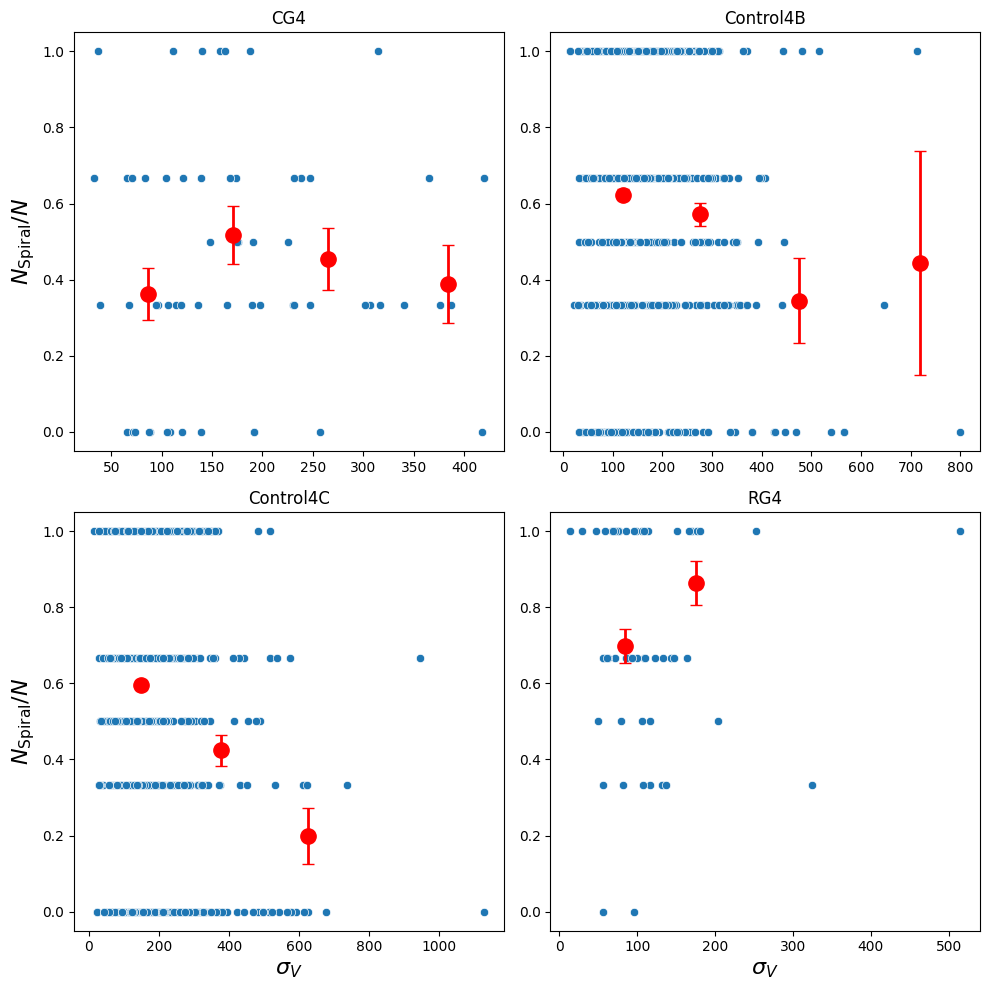

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labelsize = 16

q1 = 'Vdisp'
q2 = 'S_frac'

nbins = 4
min_bin_size = 3

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,10))

for index, cat in enumerate(co.SAMPLE.keys()):

    row = index // 2
    col = index % 2
    ax = axes[row, col]

    ax.set_title(cat)

    df = sample[cat + co.GRSUFF][[q1, q2]].dropna()
    x = df[q1].values
    y = df[q2].values

    sns.scatterplot(data=df, x=q1, y=q2, ax=ax)

    # 4 bins in x
    bin_edges = np.linspace(x.min(), x.max(), nbins+1)

    xmeans = []
    ymeans = []
    yerr = []

    for i in range(nbins):

        left = bin_edges[i]
        right = bin_edges[i+1]

        if i < nbins-1:
            mask = (x >= left) & (x < right)
        else:
            mask = (x >= left) & (x <= right)

        xb = x[mask]
        yb = y[mask]

        if len(yb) < min_bin_size:
            continue

        mean_x = np.mean(xb)
        mean_y = np.mean(yb)

        sem = np.std(yb, ddof=1) / np.sqrt(len(yb))

        xmeans.append(mean_x)
        ymeans.append(mean_y)
        yerr.append(sem)

    ax.errorbar(
        xmeans,
        ymeans,
        yerr=yerr,
        fmt='o',
        color='red',
        ecolor='red',
        elinewidth=2,
        capsize=4,
        markersize=11,
        zorder=10
    )

    if row == len(co.SAMPLE.keys())//2 -1:
        ax.set_xlabel(r'$\sigma_V$', fontsize=labelsize)
    else:
        ax.set_xlabel('')

    if col == 0:
        ax.set_ylabel(r'$N_\mathrm{Spiral}/N$', fontsize=labelsize)
    else:
        ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [100]:
sample['Control4C_Groups'].columns

Index(['Group', 'Lum_BGG', 'Lum_group', 'FracLumBGG', 'z_group', 'DeltaR12',
       'DeltaR1Grp', 'NbGal', 'RA_BGG', 'Dec_BGG', 'RA_Bary', 'Dec_Bary',
       'Radius_Bary_arcmin', 'RA_Circ', 'Dec_Circ', 'Radius_Circ_arcmin',
       'Offset_Bary', 'Offset_Circ', 'V_BGG', 'V_moy', 'Vdisp', 'Voffset',
       'all_SFR', 'Prop_M_Sat', 'Prop_M_Tot', 'Prop_G_Sat', 'Prop_G_Tot',
       'Prop_Q_Sat', 'Prop_Q_Tot', 'size_Group_Bary_kpc',
       'size_Group_Circ_kpc', 'M_group', 'Misfit_Bary', 'Misfit_Circ',
       'Vmisfit', 'is_dominated', 'E_frac_NoU_NoBGG', 'S_frac_NoU_NoBGG',
       'E_frac_NoU', 'S_frac_NoU', 'E_frac_NoBGG', 'S_frac_NoBGG', 'E_frac',
       'S_frac'],
      dtype='object')

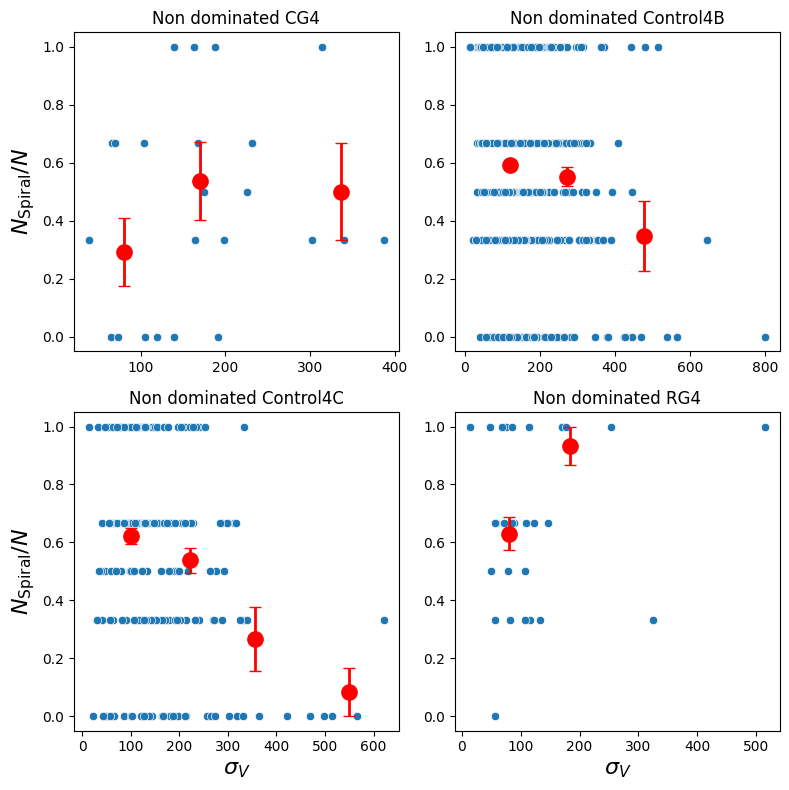

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labelsize = 16

q1 = 'Vdisp'
q2 = 'S_frac'

nbins = 4
min_bin_size = 3

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,8))

for index, cat in enumerate(co.SAMPLE.keys()):

    row = index // 2
    col = index % 2
    ax = axes[row, col]

    ax.set_title("Non dominated " + cat)

    df_inter = sample[cat + co.GRSUFF][[q1, q2,'is_dominated']].dropna()
    df = df_inter[df_inter['is_dominated'] == False]
    x = df[q1].values
    y = df[q2].values

    sns.scatterplot(data=df, x=q1, y=q2, ax=ax)

    # 4 bins in x
    bin_edges = np.linspace(x.min(), x.max(), nbins+1)

    xmeans = []
    ymeans = []
    yerr = []

    for i in range(nbins):

        left = bin_edges[i]
        right = bin_edges[i+1]

        if i < nbins-1:
            mask = (x >= left) & (x < right)
        else:
            mask = (x >= left) & (x <= right)

        xb = x[mask]
        yb = y[mask]

        if len(yb) < min_bin_size:
            continue

        mean_x = np.mean(xb)
        mean_y = np.mean(yb)

        sem = np.std(yb, ddof=1) / np.sqrt(len(yb))

        xmeans.append(mean_x)
        ymeans.append(mean_y)
        yerr.append(sem)

    ax.errorbar(
        xmeans,
        ymeans,
        yerr=yerr,
        fmt='o',
        color='red',
        ecolor='red',
        elinewidth=2,
        capsize=4,
        markersize=11,
        zorder=10
    )

    if row == len(co.SAMPLE.keys())//2 -1:
        ax.set_xlabel(r'$\sigma_V$', fontsize=labelsize)
    else:
        ax.set_xlabel('')

    if col == 0:
        ax.set_ylabel(r'$N_\mathrm{Spiral}/N$', fontsize=labelsize)
    else:
        ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
for cat in ['CG4']:
    df = sample[cat+co.GRSUFF]
    df_dom = df[df['is_dominated']]
    df_nondom = df[~df['is_dominated']]
    print(f"{cat}: {len(df_dom)} Dom, {len(df_nondom)} Non-Dom")
    for q in ['t_cr']:
        print(f"\t {q}")
        for df in [df_dom, df_nondom]:
                df_clean = df[[q, main_quantity]].dropna()
                spearcorr, spearpval = spearmanr(df_clean[q], df_clean[main_quantity])
                # if spearpval < 0.05:
                print(f"\t  -- {'' if df is df_dom else 'Non-'}Dom ({len(df_clean)} groups) p-value={spearpval:.3f}      statistic={spearcorr:.2f}")


In [62]:
sample['CG4_Groups']['Vdisp'].max()

np.float64(419.9583578978288)

In [61]:
grp = sample['CG4_Groups'].loc[sample['CG4_Groups']['Vdisp'].idxmax()]['Group']
sample['CG4_Gals'][sample['CG4_Gals']['Group'] == grp]

,objid,specobjid,Group,RA,Dec,M_r,Lum,z,dist2BGG,lgm,...,M_BGG,sSFR_status,p_E,p_S,is_dominated,morphology,sSFR_raw,sSFR_MS_offset,MS_res,sSFR_excess
60,1237648721759961111,310869352595351552,112,162.495232,0.322301,-22.785910,9.690897e+10,0.040215,0.000000,11.34712,...,-22.78591,Passive,0.949,0.000,True,Elliptical,-12.404367,NaN,NaN,-0.801676
61,1237648721759961363,309787158292490240,112,162.497479,0.353259,-21.469013,2.881411e+10,0.038864,1.950218,10.81194,...,-22.78591,Passive,0.143,0.857,True,Spiral,-11.371550,NaN,NaN,-0.032226
62,1237648721759961197,310868253083723776,112,162.525718,0.333249,-20.724521,1.451471e+10,0.041545,2.035192,10.52482,...,-22.78591,Passive,0.873,0.073,True,Elliptical,-12.130907,NaN,NaN,-0.928457
63,1237648721759961421,309796229263419392,112,162.547897,0.306911,-20.108694,8.231474e+09,0.041710,3.447380,10.23428,...,-22.78591,Passive,0.409,0.591,True,Spiral,-11.638568,NaN,NaN,-0.570980


In [65]:
sample['CG4_Gals'][sample['CG4_Gals']['Group'] == grp]['z'].to_list()

[0.040214827, 0.038863702, 0.041545466, 0.041709789]